# IBM HR Employee Attrition Analysis

#### **Phase 1. Problem Definition**

`(A).Problem Statement`

Employee attrition (employees leaving a company) costs businesses 
significant time and money through recruitment and training. 

This project aims to:
1. Understand which factors most influence employees to leave
2. Build a machine learning model to predict which employees are at risk of leaving
3. Provide actionable recommendations to the HR department

`(B).Dataset`
- Source: Kaggle (IBM HR Analytics Employee Attrition dataset)
- 1,470 employee records with 35 features

#### **Phase 2. Data Collection**
- Loads dataset into python



In [38]:
import pandas as pd   #for working with tables of data
import numpy as np    # for mathetics
import matplotlib.pyplot as plt   #for creating charts
import seaborn as sns    #for beautiful charts
from IPython.display import display #for showing tables and charts in Jupyter Notebook
import warnings 
warnings.filterwarnings('ignore') #hide unimportant warning msgs

# Load the dataset
# pd.read_csv() reads a CSV file and turns it into a 'DataFrame' (a table)

df = pd.read_csv('../data/WA_Fn-UseC_-HR-Employee-Attrition.csv')

#../ means "go up one folder level first"

In [39]:
# Show the first 5 rows to confirm it loaded correctly
print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")   # shows (rows, columns)
df.head()   # displays the first 5 rows

Dataset loaded successfully!
Shape: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


**Explanation of each line:**
- `import pandas as pd` — loads the pandas library and gives it a short name `pd`
- `df` stands for **DataFrame** — this is what data scientists call a table in Python
- `pd.read_csv(...)` — reads your CSV file and creates the table
- `df.shape` — tells you how many rows and columns you have
- `df.head()` — shows the first 5 rows so you can see the data


#### **Phase 3. Data Cleaning & Preparation**
- Find and fix problems in the data before analyzing it.



**--- Step 3.1: Understand the data ---**

In [40]:
print("=== BASIC INFORMATION ===")
display(df.info())         # shows column names, data types, and missing values
print("\n")
print("=== STATISTICAL SUMMARY ===")
display(df.describe())     # shows min, max, average, etc. for number columns

=== BASIC INFORMATION ===
<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                 

None



=== STATISTICAL SUMMARY ===


,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


**Example**

`count` - how many rows have a value in this column. 
 => No missing Values 

`mean` - eg: 36.92 avg.age 
 =>avg employee is abt 37 yrs old 

`std` -  Standard Deviation. - Measures how spread out the ages are from the avg. 
=> small std means everyone is similar age
=> large std means ages are all over place

`min` => youngest 18 yrs old

`25%` - 25th percentile *(Q1/first quartile)*. 
=> 25% of employees are aged 30 or younger.

`50%` - the *median*. 
=> half of the employee are above and below 36

`75%` - 75th percentile *(Q3/third quartile)*.
=> 75% of employees are 43 or younger

`max` => 60 years 

**1. Handling Missing Values -**

**--- Step 3.2: Check for missing values ---**

In [41]:
print("=== MISSING VALUES ===")
missing = df.isnull().sum()   # count missing values in each column
print(missing[missing > 0])   # only show columns that have missing values

=== MISSING VALUES ===
Series([], dtype: int64)


The Code, Line by Line:

Line 1: `missing = df.isnull().sum()`
This is actually doing three things chained together:

- `df` — your entire dataset (all 1470 rows, 35 columns)
- `.isnull()` — goes through every single cell in the table and asks "is this cell empty?" It returns True if empty, False if it has a value
- `.sum()` — counts up all the True values per column (because True = 1, False = 0 in Python math)

So the result is a list showing each column name and how many empty cells it has.
Line 2: `print(missing[missing > 0])`

- `missing > 0` — filters the list to only show columns where the missing count is greater than zero

The Output:

`=== MISSING VALUES ===`    
`Series([], dtype: int64)`

- `Series` — this is what pandas calls a single-column list of data
- `[]` — the square brackets are empty, meaning zero columns had missing values
- `dtype: int64` — just tells you the numbers inside would have been whole numbers (integers)

- This says that there are *NO MISSING VALUES* 

**2. Removing Duplicates -**

**--- Step 3.3: Check for duplicate rows ---**

In [42]:
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

# Remove duplicates if any exist
df = df.drop_duplicates()
print(f"Dataset size after removing duplicates: {df.shape}")

Number of duplicate rows: 0
Dataset size after removing duplicates: (1470, 35)


The Code, Line by Line:
- `df.duplicated()` - Goes through every row and checks for duplicates.
- `print (f"no of duplicate row: {duplicates})` - f-string
The f before the quotation marks means formatted string literal (f-string).
It allows you to insert variables directly inside a string using {}.
- `df.shape` - returnd the dimensions of your table as (rowa, columns).

**3. Removing Irrelevant Data -**

**--- Step 3.4: Show full table of columns to be removed ---**

In [43]:
cols_to_drop = ['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber']

# Create a table with the columns that will be removed
removed_columns_table = df[cols_to_drop]

# Display the table
display(removed_columns_table)

,EmployeeCount,StandardHours,Over18,EmployeeNumber
0,1,80,Y,1
1,1,80,Y,2
2,1,80,Y,4
3,1,80,Y,5
4,1,80,Y,7
...,...,...,...,...
1465,1,80,Y,2061
1466,1,80,Y,2062
1467,1,80,Y,2064
1468,1,80,Y,2065


**The Rule: A column is useless if it adds zero new information to the model.**     

There are two types of useless columns:
- **Type 1 — Same value for every single row (Zero Variance)**
    - If every employee has the exact same value in a column, that column tells the model absolutely nothing about why one employee leaves and another stays. It can't be a factor if everyone has it equally.
- **Type 2 — Just an ID number (Not a real feature)**
    - ID numbers are just labels to identify records — they have no relationship to attrition.

In [44]:
display(df[cols_to_drop].head())

for col in cols_to_drop:
    print(f"\n{col} unique values:")
    print(df[col].unique())

,EmployeeCount,StandardHours,Over18,EmployeeNumber
0,1,80,Y,1
1,1,80,Y,2
2,1,80,Y,4
3,1,80,Y,5
4,1,80,Y,7



EmployeeCount unique values:
[1]

StandardHours unique values:
[80]

Over18 unique values:
<StringArray>
['Y']
Length: 1, dtype: str

EmployeeNumber unique values:
[   1    2    4 ... 2064 2065 2068]


In [45]:
# --- removal of unnecessary columns ---
df = df.drop(columns=cols_to_drop)

print(f"Columns after cleanup: {df.shape[1]} columns remaining")

Columns after cleanup: 31 columns remaining


The Code, Line by Line:
-  The first code to *show the removing data frame* is a simple code, understandable.
-  The second code:

    - `print(df[cols_to_drop].head())` - Shows the first 5 rows of the columns to be removed.
        - `df` - dataset (DataFrame)
        - `.head().` - only first 5 rows.
    - `for col in cols_to_drop:` - loops through each column one by one.
    - `print(f"\n{col} unique values:")` - prints the column name.
        - `{col}` - insert the current column name    
    - `print(df[col].unique())` - shows all diff values inside that column => Since only one value is shown under each column this proves that only one value exist through out these columns.

        



**4. Covert Data Type** and **5. Encoding**
- Machine learning models can only work with numbers, not text like "Yes"/"No"
- We convert text categories into numbers — this is called *ENCODING*


**--- Step 3.5: Encode categorical (text) columns ---**

In [46]:
from sklearn.preprocessing import LabelEncoder

# Create a copy to keep the original safe
df_encoded = df.copy()

# Find all columns that contain text (called 'object' type)
categorical_cols = df_encoded.select_dtypes(include=['object']).columns

# Show the text columns
print(f"Text columns to encode:\n {list(categorical_cols)}")

# Show some sample rows of those columns
print("\nSample data before encoding:\n")
display(df_encoded[categorical_cols].head())

Text columns to encode:
 ['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

Sample data before encoding:



,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,OverTime
0,Yes,Travel_Rarely,Sales,Life Sciences,Female,Sales Executive,Single,Yes
1,No,Travel_Frequently,Research & Development,Life Sciences,Male,Research Scientist,Married,No
2,Yes,Travel_Rarely,Research & Development,Other,Male,Laboratory Technician,Single,Yes
3,No,Travel_Frequently,Research & Development,Life Sciences,Female,Research Scientist,Married,Yes
4,No,Travel_Rarely,Research & Development,Medical,Male,Laboratory Technician,Married,No


In [47]:
# Encode each text column into numbers
mapping_table = {}

le = LabelEncoder()
for col in categorical_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])
    
    # store mapping (what you want)
    mapping_table[col] = pd.DataFrame({
        "Category": le.classes_,
        "Encoded Value": le.transform(le.classes_)
    })

print("Encoding complete!")
display(df_encoded.head())

Encoding complete!


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,2,1102,2,1,2,1,2,0,...,3,1,0,8,0,1,6,4,0,5
1,49,0,1,279,1,8,1,1,3,1,...,4,4,1,10,3,3,10,7,1,7
2,37,1,2,1373,1,2,2,4,4,1,...,3,2,0,7,3,3,0,0,0,0
3,33,0,1,1392,1,3,4,1,4,0,...,3,3,0,8,3,3,8,7,3,0
4,27,0,2,591,1,2,1,3,1,1,...,3,4,1,6,3,3,2,2,2,2


The Code, Line by Line:
- `from sklearn.preprocessing import LabelEncoder` - Import LabelEncoder from scikit-learn (sklearn), which is python's main ML library.    
    *Think of it as borrowing a "test-to-no translator"*
    
- `df_encoded = df.copy()` - creates a backup copy of the cleaned data.
    
- `categorical_cols = df_encoded.select_dtypes(include=['object']).columns` - Automatically finds all columns that contain text *(pandas call text columns `object` type)*.
    
- `print(f"Text columns to encode: {list(categorical_cols)}")` - list the text of columns it found so you can see what's being encoded.

- `le = LableEncoder()` - Creates one instance of LabelENcoder tool and names it le.
    - `for col in categorical_cols:` - a loop --
    
    - `df_encoded[col] = le.fit_transform(df_encoded[col])` -  For each text column: `fit_transform` reads all the unique values in that column, assigns a number to each, and replaces the text with numbers. So *"Yes"→1, "No"→0* or *"Male"→1, "Female"→0*, etc.

- `print(df_encoded.head())` -  Shows the first 5 rows of your now fully numeric table

***How the objects where encoded into numerical values***

In [48]:
for col in mapping_table:
    print(f"\n Column: {col}")
    display(mapping_table[col])


 Column: Attrition


,Category,Encoded Value
0,No,0
1,Yes,1



 Column: BusinessTravel


,Category,Encoded Value
0,Non-Travel,0
1,Travel_Frequently,1
2,Travel_Rarely,2



 Column: Department


...

,Category,Encoded Value
0,Healthcare Representative,0
1,Human Resources,1
2,Laboratory Technician,2
3,Manager,3
4,Manufacturing Director,4
5,Research Director,5
6,Research Scientist,6
7,Sales Executive,7
8,Sales Representative,8



 Column: MaritalStatus


,Category,Encoded Value
0,Divorced,0
1,Married,1
2,Single,2



 Column: OverTime


,Category,Encoded Value
0,No,0
1,Yes,1


**6. Handling Outliers**
- Outliers are extreme values that don't fit the pattern (rest of the data)
- Box plots are the standard visual tool for spotting outliers
    - Example: If most salaries are between 2,000-10,000 but one shows 999,999
- that's probably an error

**--- Step 3.6: Check for outliers ---**

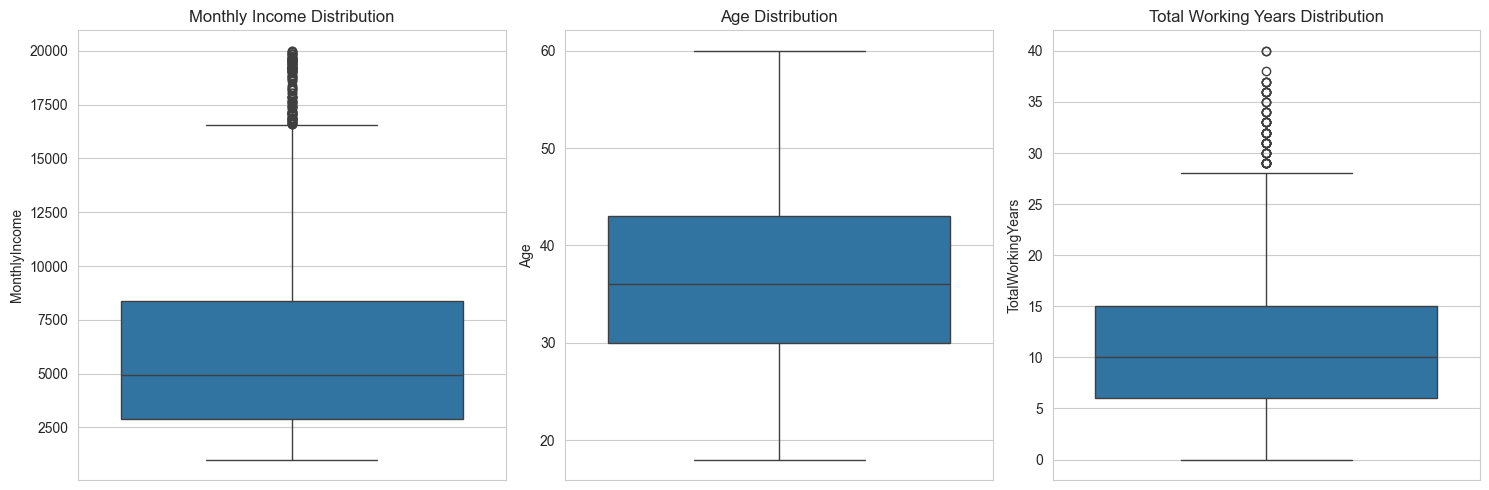

Box plots saved!


In [49]:
plt.figure(figsize=(15, 5))

# Check Monthly Income for outliers using a box plot
plt.subplot(1, 3, 1)
sns.boxplot(y=df['MonthlyIncome'])
plt.title('Monthly Income Distribution')

plt.subplot(1, 3, 2)
sns.boxplot(y=df['Age'])
plt.title('Age Distribution')

plt.subplot(1, 3, 3)
sns.boxplot(y=df['TotalWorkingYears'])
plt.title('Total Working Years Distribution')

plt.tight_layout()
plt.savefig('../outputs/charts/outlier_check.png')  # save the chart
plt.show()
print("Box plots saved!")


The Code, Line by Line:

- `plt.figure(figsize=(15, 5))`— Creates a blank canvas that is 15 units wide and 5 units tall (wide enough to fit 3 charts side by side).

- `plt.subplot(1, 3, 1)` - Says *"I want 1 row, 3 columns of charts, and I'm now drawing the 1st one."* 
    - This is how you place multiple charts on one canvas.
    - `plt.subplot(1, 3, 2) / plt.subplot(1, 3, 3)` — Move to the 2nd and 3rd chart slots

- `sns.boxplot(y=df['MonthlyIncome'])` — Draws a box plot for the MonthlyIncome column. 
    - The box shows the middle 50% of salaries. Any dots floating far above or below are outliers.

- `plt.title('Monthly Income Distribution')` — Adds a title to this chart.

- `plt.tight_layout()` — Automatically adjusts spacing so the 3 charts don't overlap each other.

- `plt.savefig('../outputs/charts/outlier_check.png')` — Saves the chart image to your outputs/charts folder. 

- `plt.show()` - Display the chart inside the notebook

**7. Nomarlization and Standardize Data**   
        
- *Normalization*
    - Normalization scales all number columns to the same range (0 to 1)
    - Why? If Age goes 0-60 and MonthlyIncome goes 0-20000, the model will wrongly think Income is more important just because it's bigger
    - Also, this step officially separates your inputs from your output, which is required before model building.

- *Standardization*
    - Transform Data so that:
        - Mean becomes 0 
        - Standard Deviation becomes 1
    - Typical range becomes around:
        - -3 to +3
    - Example:
        - Age 25 → -1.2
        - Age 37 → 0
        - Age 50 → +1.5

**Why Scaling is important in ML:**
- Example:
    - Salary = 100000
    - Age = 25

- The model may think Salary is much more important simply because the numbers are larger.
- Scaling fixes this problem.



**--- Step 3.7: Normalization AND Standardization ---**

In [50]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Separate features and target
X = df_encoded.drop('Attrition', axis=1)
y = df_encoded['Attrition']

# --- Apply Normalization (scales to 0-1) ---
min_max_scaler = MinMaxScaler()
X_normalized = min_max_scaler.fit_transform(X)
X_normalized = pd.DataFrame(X_normalized, columns=X.columns)

# --- Apply Standardization (scales to mean=0, std=1) ---
standard_scaler = StandardScaler()
X_standardized = standard_scaler.fit_transform(X)
X_standardized = pd.DataFrame(X_standardized, columns=X.columns)

print("Both scaling methods applied successfully!")
print(f"\nNormalization — Age range: {X_normalized['Age'].min():.2f} to {X_normalized['Age'].max():.2f}")
print(f"Standardization — Age range: {X_standardized['Age'].min():.2f} to {X_standardized['Age'].max():.2f}")

Both scaling methods applied successfully!

Normalization — Age range: 0.00 to 1.00
Standardization — Age range: -2.07 to 2.53


The Code, Line by Line:
- `from sklearn.preprocessing import MinMaxScaler, StandardScaler` — Imports two preprocessing tools from scikit-learn.

- `X = df_encoded.drop('Attrition', axis=1)` — Creates `X` (the features / inputs) by taking all columns except Attrition.  
    - `axis=1` means "drop a column" (as opposed to a row).   
    - `X` is everything the model will use to learn.

- `y = df_encoded['Attrition']` — Creates `y` (the target / output)
    -  just the Attrition (left the company or stayed) column alone. This is what the model is trying to predict.

**Why Reove Attrition From X?**
    - Because: ML models use `x` to predict `y`. The target column should NOT be included as an input feature.

- `min_max_scaler = MinMaxScaler()` — Sets up the scaler tool (like setting up the translator in Step 3.5).

- `X_normalized = min_max_scaler.fit_transform(X)` — this line does 2 things:
    - `fit()` - learns: Minimum and Maximum Vlue for every column.
    - `transform()` - applies the scailing formula - normalizong the data.

- `X_normalized = pd.DataFrame(X_normalized, columns=X.columns)` - converts data to DataFrame 
    - `fit_transform()` - returns a NumPy array. 
        - without this: column names disappear.
        - this restores: 
            - proper column names 
            - DataFrame format

- `standard_scaler = StandardScaler()`  - creates a standardization object


**CHART 1: Before vs Normalized vs Standardized (Single Column)**

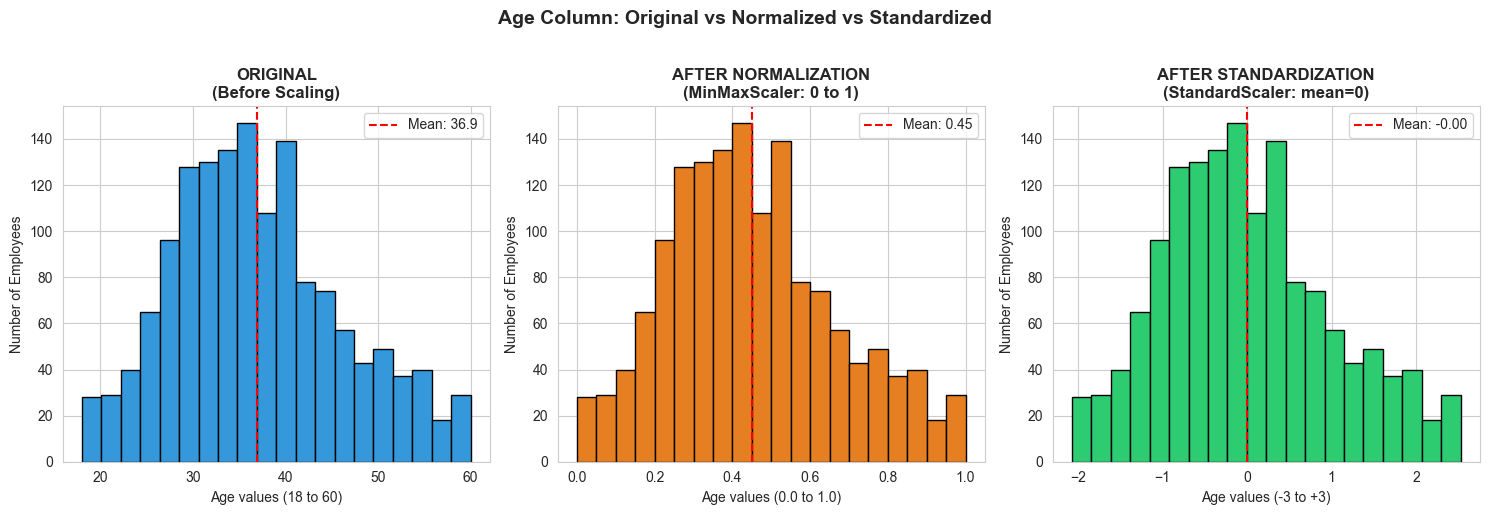

Key observation:
The SHAPE of all 3 charts is identical — the data pattern never changed.
Only the numbers on the X-axis changed.


In [51]:
# ============================================================
# This chart shows what happens to ONE column across all 3 states
# Using Age as the example since it's easy to understand

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# --- Original ---
axes[0].hist(df_encoded['Age'], bins=20, color='#3498db', edgecolor='black')
axes[0].set_title('ORIGINAL\n(Before Scaling)', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Age values (18 to 60)')
axes[0].set_ylabel('Number of Employees')
axes[0].axvline(df_encoded['Age'].mean(), color='red', linestyle='--', label=f"Mean: {df_encoded['Age'].mean():.1f}")
axes[0].legend()

# --- After Normalization ---
axes[1].hist(X_normalized['Age'], bins=20, color='#e67e22', edgecolor='black')
axes[1].set_title('AFTER NORMALIZATION\n(MinMaxScaler: 0 to 1)', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Age values (0.0 to 1.0)')
axes[1].set_ylabel('Number of Employees')
axes[1].axvline(X_normalized['Age'].mean(), color='red', linestyle='--', label=f"Mean: {X_normalized['Age'].mean():.2f}")
axes[1].legend()

# --- After Standardization ---
axes[2].hist(X_standardized['Age'], bins=20, color='#2ecc71', edgecolor='black')
axes[2].set_title('AFTER STANDARDIZATION\n(StandardScaler: mean=0)', fontweight='bold', fontsize=12)
axes[2].set_xlabel('Age values (-3 to +3)')
axes[2].set_ylabel('Number of Employees')
axes[2].axvline(X_standardized['Age'].mean(), color='red', linestyle='--', label=f"Mean: {X_standardized['Age'].mean():.2f}")
axes[2].legend()

plt.suptitle('Age Column: Original vs Normalized vs Standardized', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/charts/scaling_comparison_age.png')
plt.show()

print("Key observation:")
print("The SHAPE of all 3 charts is identical — the data pattern never changed.")
print("Only the numbers on the X-axis changed.")

The Code, Line by Line:

- `fig, axes = plt.subplots(1, 3, figsize=(15, 5))` - makes 1 row, 3 columns 
- `figsize=(15, 5)` - controls chart size (width, height)

**First Chart - Original Data**

- `axes[0].hist(df_encoded['Age'], bins=20, color='#3498db', edgecolor='black')` - shows histogram of orginal age values. *x-axis=age* and *y-axis=no.of employee*
    - `df_encoded['Age']` → Age column
    - `bins=20` → divides ages into 20 groups
    - `color` → blue bars
    - `edgecolor='black'` → black borders

- `axes[0].axvline(df_encoded['Age'].mean(), color='red', linestyle='--',label=f"Mean: {df_encoded['Age'].mean():.1f}")` - draws a vertical red line = avg age

- `axes[0].legend()` - shows the legend box [ A legend is the small box that explain what each color or line means in the chart]

**Second Chart - Normalization**

- `axes[1].hist(X_normalized['Age'], ...)` - shows the same age data after applying *MinMaxScaler*  

Fomrula:
$$x_{norm} = \frac{x - x_{min}}{x_{max} - x_{min}}$$

**Observation** - histogram shapes stays identical - only X-axis value changed, Scale changed

- `label=f"Mean: {X_normalized['Age'].mean():.2f}"` - Mean Line - `:.2f` - 2 decimal places

**Thrid Chart - Standardization**

Formula:
$$
z = \frac{x - \mu}{\sigma}
$$
- Where:
    - x = original value
    - μ = mean
    - σ = standard deviation

- `plt.tight_layout()` - fixes spacing automatically 

**CHART 2: Multiple Columns — Before vs After Both Methods**

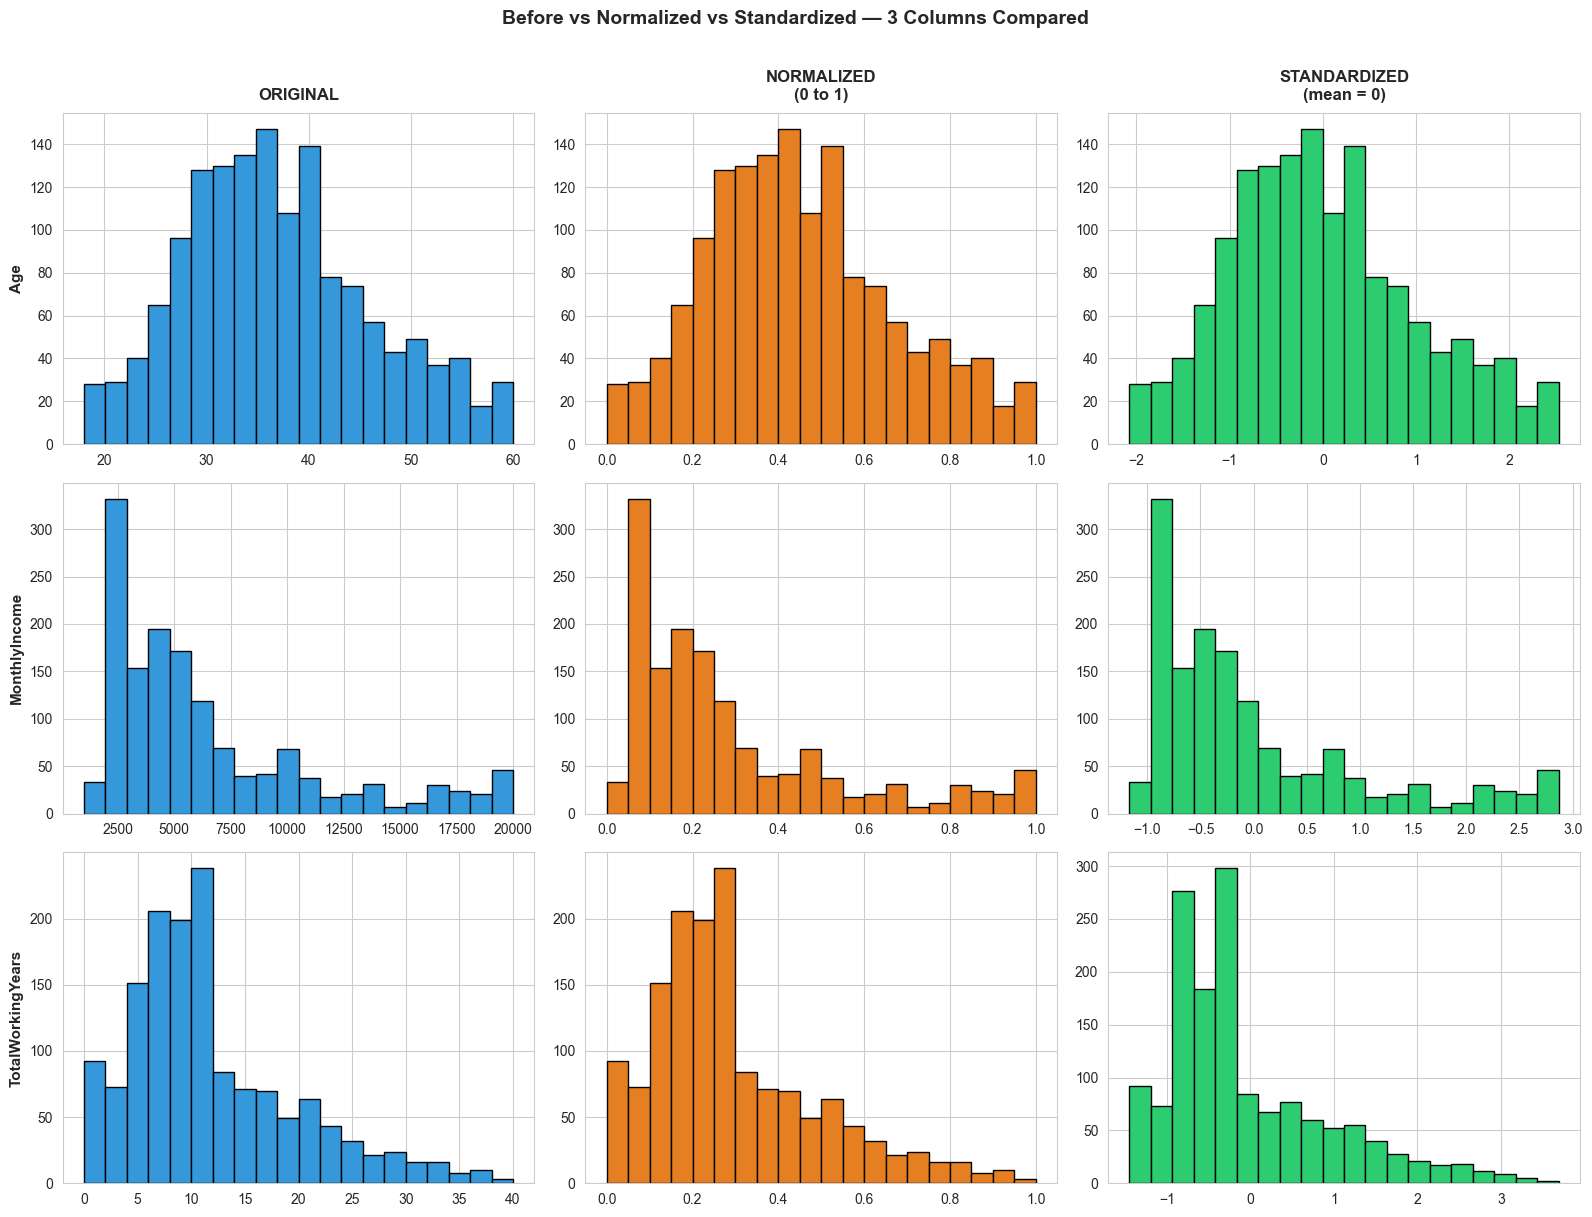

In [52]:
# ============================================================
# Shows 3 columns across all 3 states in a grid

columns_to_show = ['Age', 'MonthlyIncome', 'TotalWorkingYears']
colors = ['#3498db', '#e67e22', '#2ecc71']
titles = ['ORIGINAL', 'NORMALIZED\n(0 to 1)', 'STANDARDIZED\n(mean = 0)']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))

for row, col in enumerate(columns_to_show):
    # Original
    axes[row][0].hist(df_encoded[col], bins=20, color=colors[0], edgecolor='black')
    axes[row][0].set_ylabel(col, fontsize=11, fontweight='bold')
    
    # Normalized
    axes[row][1].hist(X_normalized[col], bins=20, color=colors[1], edgecolor='black')
    
    # Standardized
    axes[row][2].hist(X_standardized[col], bins=20, color=colors[2], edgecolor='black')

# Add column headers at the top
for col_idx, title in enumerate(titles):
    axes[0][col_idx].set_title(title, fontsize=12, fontweight='bold', pad=10)

plt.suptitle('Before vs Normalized vs Standardized — 3 Columns Compared',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../outputs/charts/scaling_comparison_multiple.png')
plt.show()

**CHART 3: Range Comparison Bar Chart**

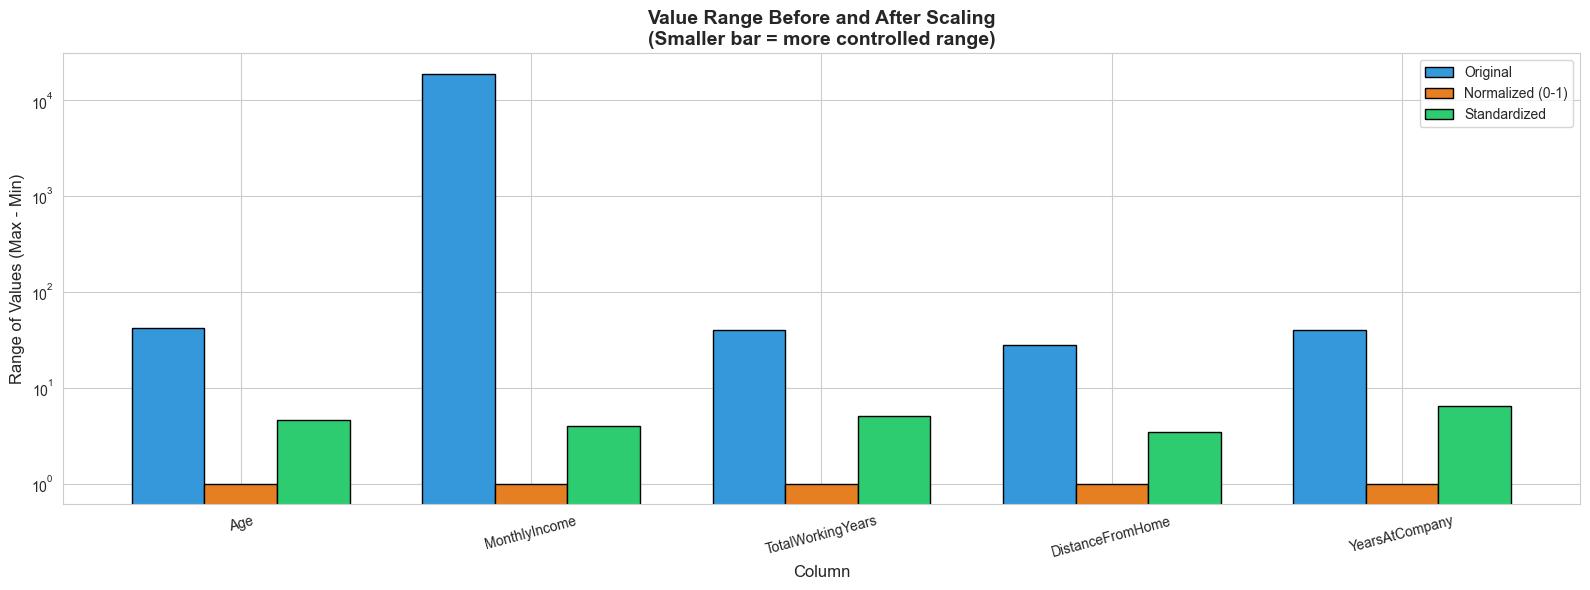

Notice: MonthlyIncome originally had a massive range compared to Age.
After both scaling methods, all columns are brought to a comparable range.


In [53]:
# ============================================================
# Shows how different the ranges were before scaling
# and how both methods bring them to a similar range

columns_to_compare = ['Age', 'MonthlyIncome', 'TotalWorkingYears', 
                       'DistanceFromHome', 'YearsAtCompany']

original_ranges = [df_encoded[col].max() - df_encoded[col].min() for col in columns_to_compare]
normalized_ranges = [X_normalized[col].max() - X_normalized[col].min() for col in columns_to_compare]
standardized_ranges = [X_standardized[col].max() - X_standardized[col].min() for col in columns_to_compare]

x = range(len(columns_to_compare))
width = 0.25

fig, ax = plt.subplots(figsize=(16, 6))

bars1 = ax.bar([i - width for i in x], original_ranges, width, 
               label='Original', color='#3498db', edgecolor='black')
bars2 = ax.bar(x, normalized_ranges, width, 
               label='Normalized (0-1)', color='#e67e22', edgecolor='black')
bars3 = ax.bar([i + width for i in x], standardized_ranges, width, 
               label='Standardized', color='#2ecc71', edgecolor='black')

ax.set_xlabel('Column', fontsize=12)
ax.set_ylabel('Range of Values (Max - Min)', fontsize=12)
ax.set_title('Value Range Before and After Scaling\n(Smaller bar = more controlled range)', 
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(columns_to_compare, rotation=15)
ax.legend()
ax.set_yscale('log')
plt.tight_layout()
plt.savefig('../outputs/charts/scaling_range_comparison.png')
plt.show()

print("Notice: MonthlyIncome originally had a massive range compared to Age.")
print("After both scaling methods, all columns are brought to a comparable range.")

The Code, Line by Line:
- `fig, ax = plt.subplots()` 
    - `fig` - the whole figure/window
    - `ax` - the actual chart area (axes)
    - `ax.bar(...)` - Draw a bar chart on this graph area
    
- `ax.set_yscale('log')` - Changes the Y-axis into: logarithmic scale instead of normal scale.
     - normal scale -> 0, 1000, 2000, 3000 = Equal Scaling
     - log scale -> 1, 10, 100, 1000, 10000 = spacing based on multiplication 

- `ax.set_xticks(x)` - Sets the positions of the labels/ticks on the X-axis.

- `rotation=15` - with rotation labels tilt slightly for readability.

**PRINT SUMMARY — Side by side comparison**

In [54]:
# ============================================================

print("=" * 60)
print("SCALING METHODS SUMMARY")
print("=" * 60)
print(f"{'Column':<22} {'Original Range':<20} {'Normalized':<18} {'Standardized'}")
print("-" * 79)

for col in ['Age', 'MonthlyIncome', 'TotalWorkingYears']:
    orig = f"{df_encoded[col].min():.0f} to {df_encoded[col].max():.0f}"
    norm = f"{X_normalized[col].min():.2f} to {X_normalized[col].max():.2f}"
    std  = f"{X_standardized[col].min():.2f} to {X_standardized[col].max():.2f}"
    print(f"{col:<22} {orig:<20} {norm:<18} {std}")

print("\nConclusion:")
print("Normalization → always exactly 0.00 to 1.00")
print("Standardization → varies, but always centered at 0")

SCALING METHODS SUMMARY
Column                 Original Range       Normalized         Standardized
-------------------------------------------------------------------------------
Age                    18 to 60             0.00 to 1.00       -2.07 to 2.53
MonthlyIncome          1009 to 19999        0.00 to 1.00       -1.17 to 2.87
TotalWorkingYears      0 to 40              0.00 to 1.00       -1.45 to 3.69

Conclusion:
Normalization → always exactly 0.00 to 1.00
Standardization → varies, but always centered at 0


#### **Phase 4: EXPLORATORY DATA ANALYSIS (EDA)**

**What:** Visualize and explore the data to find patterns   
**Why:** You need to understand the data before building a model. EDA answers questions like "Who is leaving?" and "Why are they leaving?"  
**Where:** After cleaning, before modeling.

**Chart 1 - How many employee left vs stayed?**

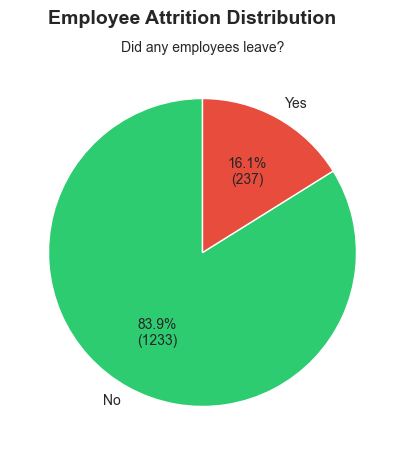

In [55]:
# Set a nice style for all charts
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# --- Chart 1: How many employees left vs stayed? ---
plt.figure(figsize=(8, 5)) # creates new chart canvas
attrition_counts = df['Attrition'].value_counts()
colors = ['#2ecc71', '#e74c3c']   # green for No, red for Yes
plt.pie(attrition_counts.values, 
        labels=attrition_counts.index, 
        # autopct='%1.1f%%', -- show percentage
        # autopct=lambda p: f'{int(round(p * sum(attrition_counts) / 100))}', --show count instead of percentage
        autopct=lambda p: f'{p:.1f}%\n({int(round(p * sum(attrition_counts) / 100))})', # show both percentage and count
        colors=colors,
        startangle=90)
plt.suptitle('Employee Attrition Distribution', fontsize=14, fontweight='bold')
plt.title('Did any employees leave?', fontsize=10)
plt.savefig('../outputs/charts/01_attrition_distribution.png')
plt.show()


The Code, Line by Line:

- `sns.set_style("whitegrid")` - Sets the background style for all charts ( white background with light grid lines)

- `plt.rcParams['figure.figsize'] = (10, 6)` - Sets the default chart size for everything that follows   
    - `(10, 6)` = (width, height) in inches

- `attrition_counts = df['Attrition'].value_counts()` - Counts how many employees -> stayed == No , left == Yes

- `plt.pie` - PIE chart

-  `attrition_counts.values` - uses the count as slice sizes

- l`abels=attrition_counts.index` - adds label to lsices 

- `autopct='%1.1f%%'` - displays percentsges on slices 
    - `%1.1f%%` - shows float no, with decimal 1, followed by %

    - `{p:.1f}%` - shows percentage with 1 decimal point 

- `int(round(p * sum(attrition_counts) / 100))` converts percentage back into actual employee no.

- `startangle=90` - rotates the chart starting point.



**Chart 2 -How many Attrition by department ?**

<Figure size 1000x600 with 0 Axes>

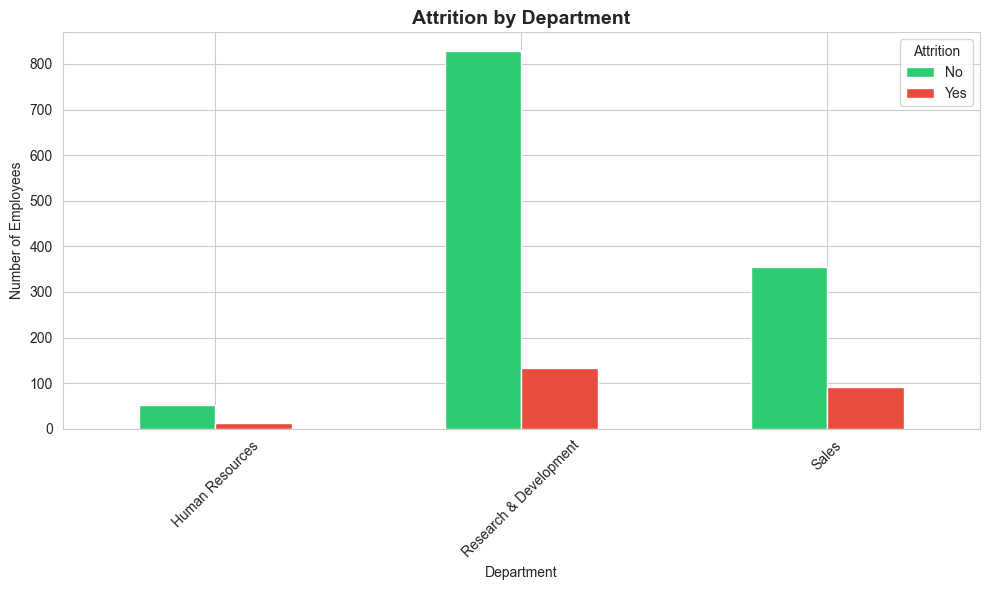

In [56]:
# --- Chart 2: Attrition by Department ---
plt.figure(figsize=(10, 6))
dept_attrition = df.groupby(['Department', 'Attrition']).size().unstack()
dept_attrition.plot(kind='bar', color=['#2ecc71', '#e74c3c'])
plt.title('Attrition by Department', fontsize=14, fontweight='bold')
plt.xlabel('Department')
plt.ylabel('Number of Employees')
plt.xticks(rotation=45)
plt.legend(title='Attrition')
plt.tight_layout()
plt.savefig('../outputs/charts/02_attrition_by_department.png')
plt.show()


**Chart 3 -Age Distribution by Attrition**

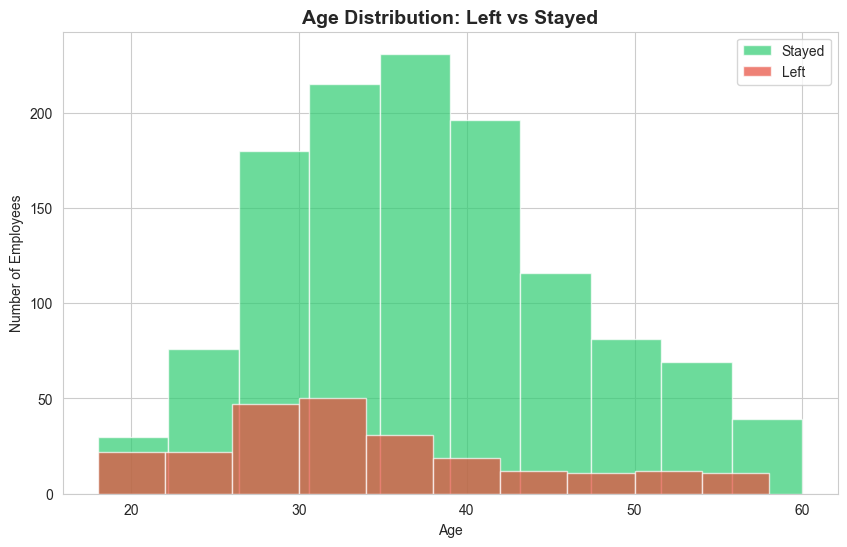

In [57]:
# --- Age Distribution by Attrition ---
plt.figure(figsize=(10, 6))
df[df['Attrition'] == 'No']['Age'].hist(alpha=0.7, color='#2ecc71', label='Stayed')
df[df['Attrition'] == 'Yes']['Age'].hist(alpha=0.7, color='#e74c3c', label='Left')
plt.title('Age Distribution: Left vs Stayed', fontsize=14, fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Number of Employees')
plt.legend()
plt.savefig('../outputs/charts/03_age_distribution.png')
plt.show()


The Code, Line by Line:

- `df[df['Attrition'] == 'No']['Age'].hist(alpha=0.7, color='#2ecc71', label='Stayed')` 

    - `df['Attrition']` - Gets employees who stayed 

    - `df[df['Attrition'] == 'No']` - creates filtered dataframe.

    - `['Age']` - select age column 

    - `hist(..)` - creates histogram with x-axis->age ranges  and y-axis ->no.of employees

    - `alpha=0.7`  - transparency -> 1=solid , 0=invisible

    

**Chart 4 - Monthly Income vs Attrition**

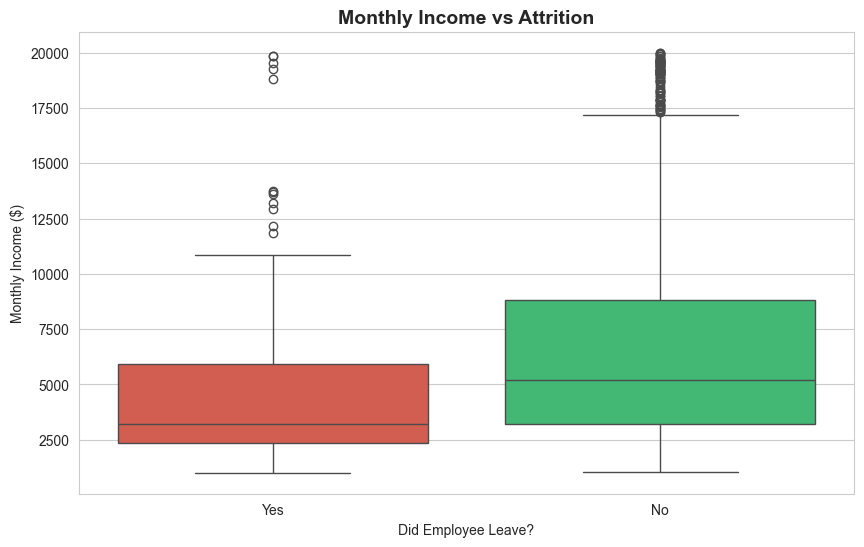

In [58]:
# --- Monthly Income vs Attrition ---
plt.figure(figsize=(10, 6))
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df, 
            palette={'Yes': '#e74c3c', 'No': '#2ecc71'})
plt.title('Monthly Income vs Attrition', fontsize=14, fontweight='bold')
plt.xlabel('Did Employee Leave?')
plt.ylabel('Monthly Income ($)')
plt.savefig('../outputs/charts/04_income_vs_attrition.png')
plt.show()


A **box plot** summarizes data distribution.

It shows:
- minimum
- maximum
- median
- spread of data
- outliers

Very useful for comparing groups.

**Median Line** - the line inside the box = middle salary value 

**Box Area** - Represents the middle 50% of data called the *Interquartile Range (IQR)* shows where most salaries are concentrated.

**Whiskers** - Lines extending from box - shows normal range of salaries

**Dots Outside** - Outliers. Employees with unusually high or low salaries 

`yes` -> Employees who left 
`no`  -> Employees who stayed 

--------------------------------------------------------------
The Code, Line by Line:

- `sns.boxplot(...)` uses seaborn to create a box plot. seaborn is built on top of Matplotlib and makes charts look cleaner.

- `x='Attrition'` - places attrition categories on horizontal axis => gets 2 boxes

- `y='MonthlyIncome'` - vertial axis shows salary values 

- `data=df` uses dataframes 



**Chart 5 -  Overtime vs Attrition (Bar Chart)**

<Figure size 800x600 with 0 Axes>

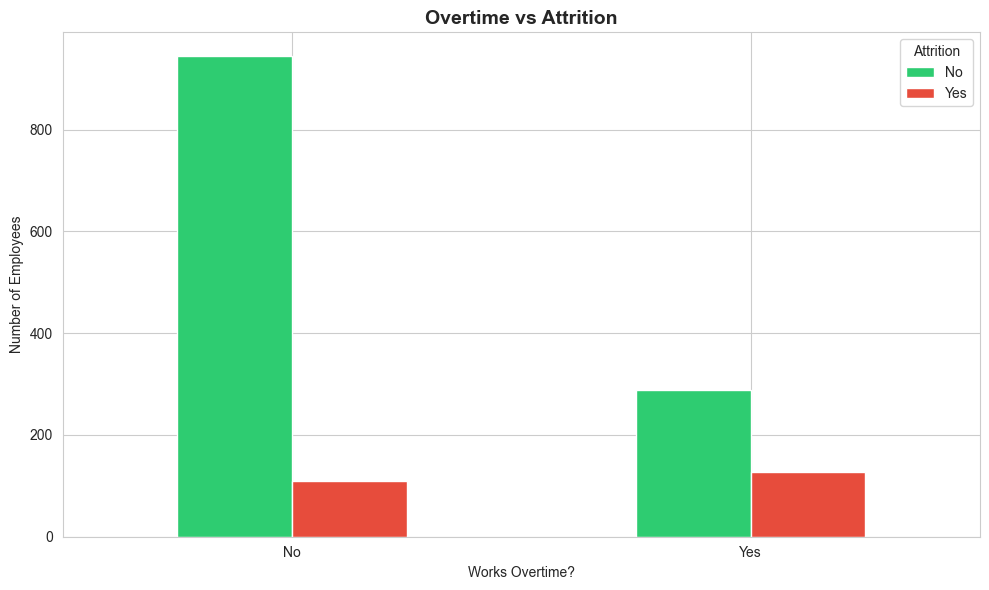

In [59]:
# --- Overtime vs Attrition ---
plt.figure(figsize=(8, 6))
overtime_attrition = df.groupby(['OverTime', 'Attrition']).size().unstack()
overtime_attrition.plot(kind='bar', color=['#2ecc71', '#e74c3c'])
plt.title('Overtime vs Attrition', fontsize=14, fontweight='bold')
plt.xlabel('Works Overtime?')
plt.ylabel('Number of Employees')
plt.xticks(rotation=0)
plt.legend(title='Attrition')
plt.tight_layout()
plt.savefig('../outputs/charts/05_overtime_vs_attrition.png')
plt.show()


The Code, Line by Line:

- `overtime_attrition = df.groupby(['OverTime', 'Attrition']).size().unstack()` 

    - `df.groupby(['OverTime', 'Attrition'])` - group data by OverTime and Attrition 

    - `.size()` - counts employees in each combination 

    - `.unstack()` - transform the table into chart-friendily format 
    
        - Before unstack:
            | OverTime | Attrition | Count |
            | -------- | --------- | ----- |
            | Yes      | Yes       | 127   |

        - After unstack:
            | OverTime | No  | Yes |
            | -------- | --- | --- |
            | No       | 944 | 110 |
            | Yes      | 289 | 127 |

- `plt.xticks(rotation=0)` - keeps label horizontal 

- `plt.tight_layout()` - automatically fixes spacing issues. Prevents overlapping label and cut-off text.

    

**Chart 6 — Correlation Heatmap**

- A heatmap shows how strongly each column is related to each other column

- Heatmapis one of the most important charts in data analysis and machine learning because it helps identify:
    - strong relationships
    - redundant features
    - patterns
    - possible predictors of attrition

*What is **Correlation** ?*

- Correlation measures the relationship between two variables. It Tells Us: 
    - Whether 2 variables move together 
    - How strong that relationship is 

- Value Range: -1 <= r <= 1

- where:    
    | Correlation Value | Meaning                       |
    | ----------------- | ----------------------------- |
    | +1                | Perfect positive relationship |
    | 0                 | No relationship               |
    | -1                | Perfect negative relationship |

- Example : 
    | Correlation                 | Meaning                              |
    | --------------------------- | ------------------------------------ |
    | Age & Income = +0.7         | Older employees tend to earn more    |
    | Overtime & Attrition = +0.5 | More overtime → more employees leave |
    | JobLevel & Attrition = -0.3 | Higher job levels leave less         |


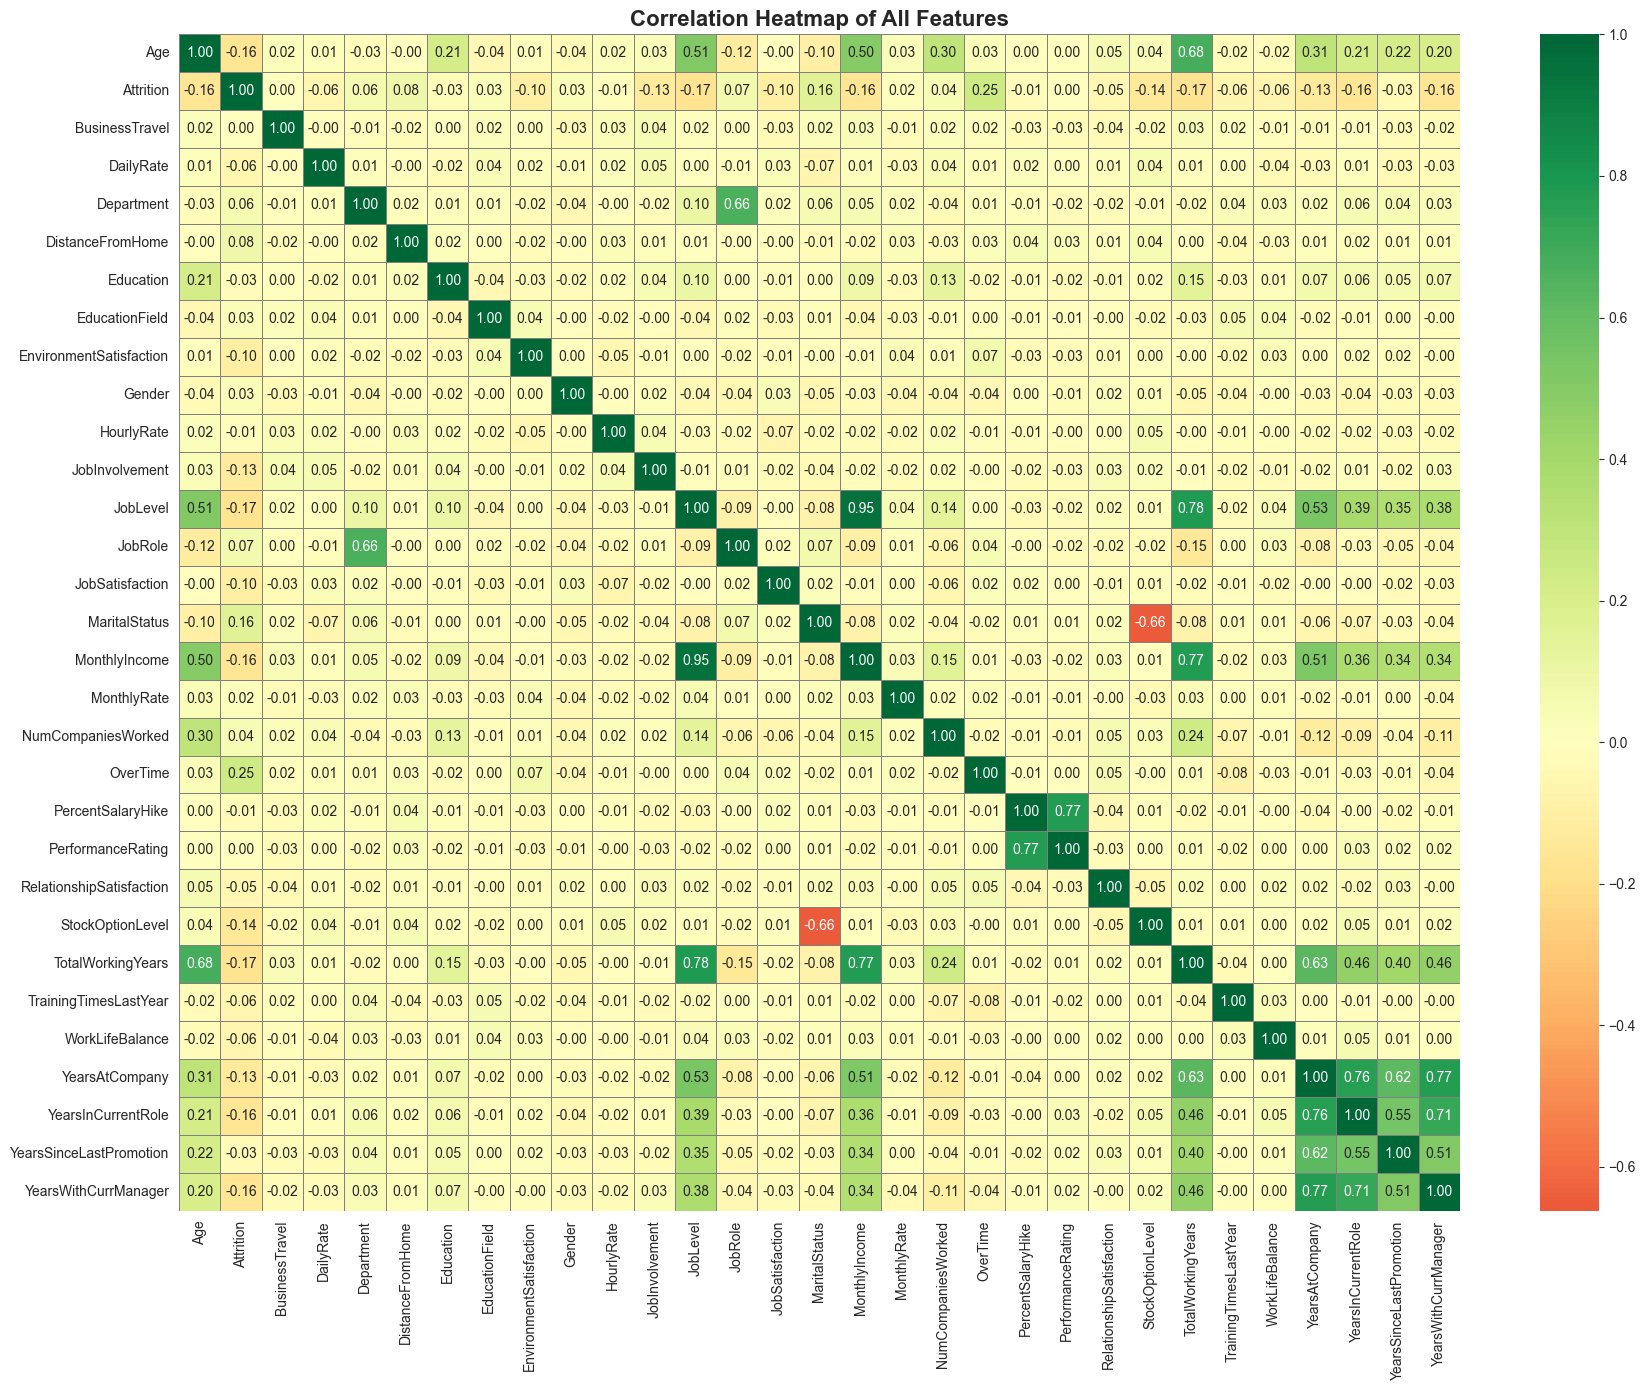

In [60]:
# --- Correlation Heatmap ---

plt.figure(figsize=(18, 14))
correlation = df_encoded.corr()
sns.heatmap(correlation, 
            annot=True,
            fmt='.2f',      # don't write numbers (too cluttered)
            cmap='RdYlGn',    # Red = negative, Yellow = neutral, Green = positive
            center=0,
            linewidths=0.5,      # thickness of borders
            linecolor='grey')    # border color
plt.title('Correlation Heatmap of All Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/charts/06_correlation_heatmap.png')
plt.show()


The Code, Line by Line:

- `correlation = df_encoded.corr()` - this computes correlation between every numerical column  
    - `df_encoded` is uded instead of `df` because correlation only works with numbers 

- categorical columns were probaly converted using: 
    - Label Encoding 
    - One-Hot Encoding 

What `.corr()` produces 

- it creates a matrix like:
    |           | Age   | Income | Attrition |
    | --------- | ----- | ------ | --------- |
    | Age       | 1.00  | 0.50   | -0.10     |
    | Income    | 0.50  | 1.00   | -0.20     |
    | Attrition | -0.10 | -0.20  | 1.00      |

    - each variable is perfectly correlated with itself:
        - *corr(X,X)=1*
        this why daigonal cells are always dark green 

- `sns.heatmap(correlation,annot=False, cmap='RdYlGn', center=0)` - uses seaborn to visualize the correlation matrix using colors.
    - `correlation` - the correlation matrix becomes the heatmap input 
    - `annot=False` - controls whether no are wrtten inside cells.
        - `true` -> shows correlation values 
        - `False` -> hides them 
        - used False because too many variables and no would clutter the chart

    - `cmap='RdYlGn'` - defines color scheme.
        - Red -> negative correlation
        - Yellow -> neutral 
        - Green -> positive correlation

    - `center=0` - centers color scales at zero correlation. So:
        - 0 becomes netral- yellow
        - +ve becomes greener
        - -ve becomes redder
        
- **How to read Heatmap Colors :**

    | Color       | Meaning                     |
    | ----------- | --------------------------- |
    | Dark Green  | Strong positive correlation |
    | Light Green | Weak positive correlation   |
    | Yellow      | Almost no correlation       |
    | Orange/Red  | Negative correlation        |

**Why Heatmap are useful**:
- Strong prediction  [eg: OT strongly correlated with attrition] could mean OT contributes to resignation.

- Multicollinearity [ if 2 variables are highly correlated - they may contain similar infromation ]

- Irrelevant Features [ variables near 0 correletaion with attrition may not be useful predictors ]



    


**Chart 7 — Job Satisfaction vs Attrition (Bar Chart)**

<Figure size 1000x600 with 0 Axes>

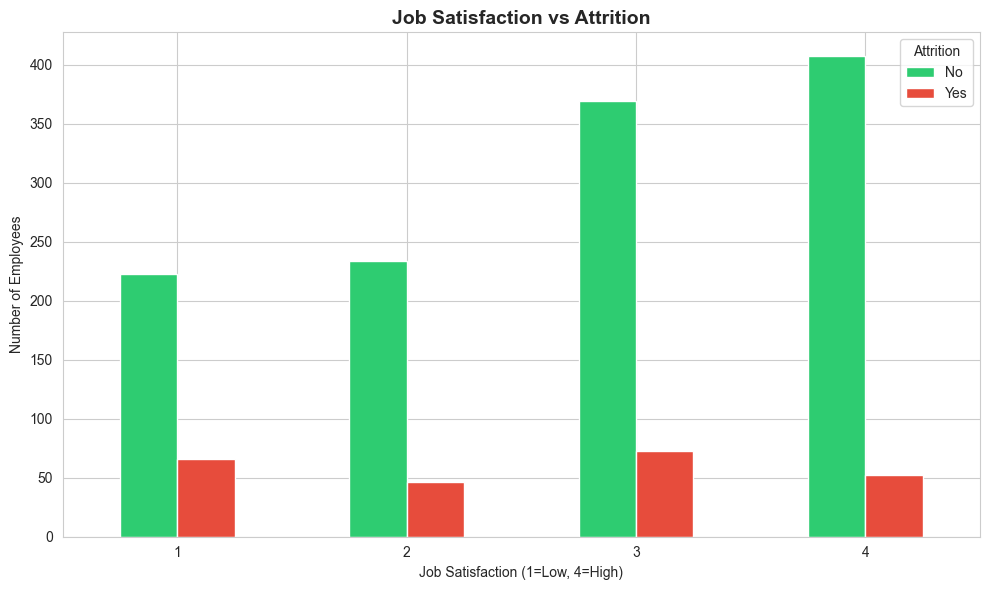

In [61]:
# --- Job Satisfaction vs Attrition ---
plt.figure(figsize=(10, 6))
sat_attr = df.groupby(['JobSatisfaction', 'Attrition']).size().unstack()
sat_attr.plot(kind='bar', color=['#2ecc71', '#e74c3c'])
plt.title('Job Satisfaction vs Attrition', fontsize=14, fontweight='bold')
plt.xlabel('Job Satisfaction (1=Low, 4=High)')
plt.ylabel('Number of Employees')
plt.xticks(rotation=0)
plt.legend(title='Attrition')
plt.tight_layout()
plt.savefig('../outputs/charts/07_satisfaction_vs_attrition.png')
plt.show()


**What the Chart shows**
- x-axis contains satisfaction levels:
    | Value | Meaning           |
    | ----- | ----------------- |
    | 1     | Low satisfaction  |
    | 2     | Medium-low        |
    | 3     | Medium-high       |
    | 4     | High satisfaction |

**Goal of This Analysis**

To see whether:
- low satisfaction employees resign more
- high satisfaction employees stay more

The Code, Line by Line:

- `sat_attr = df.groupby(['JobSatisfaction', 'Attrition']).size().unstack()` - prepares the data for plotting by grouping the data

    -  `groupby(['JobSatisfaction', 'Attrition'])` - employees grouped by the Satusfaction Level and Attrition Status.

    - `.size()` - counts how many employees exist in each group 

    -  `.unstack()` - transforms data into chart-friendily format 

- `sat_attr.plot(kind='bar', color=['#2ecc71','#e74c3c'])` - Plots grouped bar chart



**Key Findings Summary**

In [62]:
print(f"1. Attrition rate: {(df['Attrition'] == 'Yes').mean()*100:.1f}% of employees left")
print(f"2. Avg age of employees who left: {df[df['Attrition']=='Yes']['Age'].mean():.1f} years")
print(f"3. Avg income of employees who left: ${df[df['Attrition']=='Yes']['MonthlyIncome'].mean():.0f}")
print(f"4. Avg income of employees who stayed: ${df[df['Attrition']=='No']['MonthlyIncome'].mean():.0f}")
overtime_left = df[df['Attrition']=='Yes']['OverTime'].value_counts(normalize=True)['Yes']*100
print(f"5. % of leavers who worked overtime: {overtime_left:.1f}%")

1. Attrition rate: 16.1% of employees left
2. Avg age of employees who left: 33.6 years
3. Avg income of employees who left: $4787
4. Avg income of employees who stayed: $6833
5. % of leavers who worked overtime: 53.6%


#### **PHASE 5: Model Building**

**What:** Build a machine learning model that can predict if an employee will leave.

**Why:** This is the core of data science — creating something intelligent from data.

**Where:** After EDA is complete.



In [63]:
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier



The Code, Line by Line:

- `from sklearn.model_selection import train_test_split` - this is used to divide data into: 
    - Training Data - model learns pattern from it 
        - ex: Employee with low salary/OT may leave  
    - Testing Data - checks whether the model can predict correctly on new unseen data 
        
**Why Spilt Data ?**
- A ML model must be tested on unseen data, if train and test using the same data:
    - Model may memorize answeres
    - evaluation becomes unrealistic 
    - Common Split of data : Training 80% & Testing 20%

- `from sklearn.linear_model import LogisticRegression` - Logistic Regression. Used mainly for:
    - binary classification problems 
    - ex: Attrition = Yes / No
    - How Logistic Regression works - predicts probability values betweeen 0 and 1.
    - Logistic Function - Algorithm uses the Sigmoid function -> this coverts ouptuts into probabilities.
    $${\sigma}(z) = \frac{1}{1 + e^{-z}}$$

- `from sklearn.ensemble import RandomForestClassifier` - imports Random Forest - it creates MANY decision trees and combine their predictions.

- `from sklearn.tree import DecisionTreeClassifier` - imports decision tree model . - this split data using conditions 

| Decision Tree      | Random Forest       |
| ------------------ | ------------------- |
| One tree           | Many trees          |
| Simpler            | More accurate       |
| Can overfit easily | Reduces overfitting |


--------------------------------------------------------------


**--- Step 5.1: Split data into Training and Testing sets ---**

We can't test the model on data it already learned from (that would be cheating!)

So we split: 80% for training, 20% for testing


In [64]:
X_train, X_test, y_train, y_test = train_test_split(
    X_standardized,    # features (inputs)
    y,           # target (output - Attrition Yes/No)
    test_size=0.2,        # 20% goes to testing
    random_state=42,      # ensures we get the same split every time we run
    stratify=y            # keeps the Yes/No ratio balanced in both sets
)

print(f"Training set size: {X_train.shape[0]} employees")
print(f"Testing set size: {X_test.shape[0]} employees")

Training set size: 1176 employees
Testing set size: 294 employees


The Code, Line by Line:

| Variable  | Meaning           |
| --------- | ----------------- |
| `X_train` | Training features |
| `X_test`  | Testing features  |
| `y_train` | Training labels   |
| `y_test`  | Testing labels    |

- `test_size=0.2` - 20% for testing 
    - ex: Suppose dataset 1000 => 200-testing , 800-training 

- `random_state=42` - ensures the split stayr the same every time you run the notebook. 
    - Without it : data split differently every run

**--- Step 5.2: Build Model 1 — Logistic Regression ---**
- Logistic Regression is a simple, fast algorithm for Yes/No predictions
- Good starting point (like a smart calculator)

In [65]:
lr_model = LogisticRegression(max_iter=1000, 
                              random_state=42)
lr_model.fit(X_train, 
             y_train)   # "fit" = teach the model using training data
print("Logistic Regression model trained!")

Logistic Regression model trained!


The Code, Line by Line:

- `lr_model = LogisticRegression(max_iter=1000, random_state=42)` - creates the machine learning model object 

- `LogisticRegression()` - classification algorithm used for: 
    - Yes/No predictions 
    - Binary classification problems 

- `max_iter=1000` - allows the model up to 1000 learning iterations.
    - Logistic Regression learns using optimization.
    - it repeatedly adjust weights until:
        - prediction error becomes minimal 
    - each adjustment step is called *Iteration*
    - the model doesn't usually continue until `max_iter` - it automaticlly stops when the error improvement becomes extremely small. This is called *Convergence*

- `lr_model.fit(X_train, y_train)` 
    - `.fit()` - teaches model using training data 
    - the model studies:
        - input features (`x_train`)
        - correct answers (`y_train`), and learns patterns

- Logistic Regression uses The Sigmoid Function 



**--- Step 5.3: Build Model 2 — Random Forest ---***
- Random Forest builds many decision trees and combines their answers
- Usually more accurate than a single model


In [66]:

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
print("Random Forest model trained!")


Random Forest model trained!


**What is Random Forest?**
- is: a collection of many decision trees working together as a team combing all the predictions
- Random Forest uses a method called: *Bootstrap Sampling*
    - Each tree trains on:
        - random subset of rows instead of the full dataset
- Random Feature Selection 
    - at each split : the tree only checks random features instead of all columns. This increases diversity among trees.

- `n_estimators=100` - build 100 decision trees 

- `rf_model.fit(X_train, y_train)` - teaches the forest using training data 
    - `.fit()` the algorithm:
        1. creates many decision trees
        2. gives each tree random training samples
        3. each tree learns patterns
        4. combines all trees into a forest


**--- Step 5.4: Build Model 3 — Decision Tree ---**
- A decision tree asks a series of Yes/No questions to reach a conclusion
- Most explainable model — easy to understand why it made a decision


In [67]:

dt_model = DecisionTreeClassifier(max_depth=5, 
                                  random_state=42)
dt_model.fit(X_train, y_train)
print("Decision Tree model trained!")


Decision Tree model trained!


**What is Decision Tree?**
- works like a flowchart 
- the tree continues splitting until it makes predictions

The Code, Line by Line:

- `max_depth=5` - the tree can grow upto 5 levels deep 

**Why Linit the Depth?**
- Without limits: 
    - the tree may memorize training data 
    - overfitting happens 
        - Overfitting -> the model learns training data too perfectly and performs badly on new unseen data 

**How Does It Choose Splits?**
- The tree tries to reduce impurity.
- Common metrics:
    - Gini Impurity
    - Entropy
- The goal is:
    - separate classes as clearly as possible



#### **PHASE 6 — Model Evaluation**

- **What:** Test how well your models perform and compare them.
- **Why:** Your lecturer said "Testing how well the model works" is a critical step. A model is useless if it's not accurate.
- **Where:** Right after building the models.

In [68]:

# ============================================================

from sklearn.metrics import (accuracy_score, classification_report, 
                              confusion_matrix, ConfusionMatrixDisplay)
# all the improts are performance tools 

def evaluate_model(model, name, X_test, y_test):
    """Function to evaluate a model and print results"""
    # Make predictions on the test set
    y_pred = model.predict(X_test)
    
    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)
    
    print(f"\n{'='*50}")
    print(f"MODEL: {name}")
    print(f"{'='*50}")
    print(f"Accuracy: {accuracy*100:.2f}%")
    print("\nDetailed Report:")
    print(classification_report(y_test, y_pred))
    
    return accuracy

# Evaluate all three models
lr_acc = evaluate_model(lr_model, "Logistic Regression", X_test, y_test)
rf_acc = evaluate_model(rf_model, "Random Forest", X_test, y_test)
dt_acc = evaluate_model(dt_model, "Decision Tree", X_test, y_test)



MODEL: Logistic Regression
Accuracy: 87.41%

Detailed Report:
              precision    recall  f1-score   support

           0       0.89      0.97      0.93       247
           1       0.69      0.38      0.49        47

    accuracy                           0.87       294
   macro avg       0.79      0.68      0.71       294
weighted avg       0.86      0.87      0.86       294


MODEL: Random Forest
Accuracy: 83.67%

Detailed Report:
              precision    recall  f1-score   support

           0       0.85      0.97      0.91       247
           1       0.46      0.13      0.20        47

    accuracy                           0.84       294
   macro avg       0.66      0.55      0.55       294
weighted avg       0.79      0.84      0.80       294


MODEL: Decision Tree
Accuracy: 84.35%

Detailed Report:
              precision    recall  f1-score   support

           0       0.86      0.97      0.91       247
           1       0.53      0.19      0.28        47

    a

The Code, Line by Line:
- `from sklearn.metrics import (ccuracy_score,classification_report, confusion_matrix, ConfusionMatrixDisplay)` - performance measurement tools

- `accuracy_score` - used to calculate: accuracy 
    - Formula:
         $${Accuracy} = \frac{Correct Predictions}{Total Predictions}$$

- `classification_report` - provides detailed evaluation metrics:
    - Precision
        - Formula:
            $${Precision} = \frac{TP}{TP + FP}$$
        - measure: 
            - when model predicts "Leave", how often is it correct?
    - Recall
        - Formula:
            $${Recall} = \frac{TP}{TP + FN}$$
        - measure: 
            - How many actual leaving employees were detected?
    - F1 - score
        - Formula:
            $${F1} = 2.\frac{Precision. Recall}{Precision + Recall}$$
        - balances: 
            - Precision and recall
    - Support , for each class

    | Term | Meaning           |               |
    | ---- | ----------------- |---------------|
    | TP   | True Positive     | Correct “Yes” |
    | FP   | False Positive    | Wrong “Yes”   |
    | TN   | True Negative     | Correct “No”  |
    | FN   | False Negative    | Wrong “No”    |



- `confusion_matrix` - shows Correct prediction and/or Incorrect predictions in table form 

- `ConfusionMatrixDisplay` - used later to visualize the confusion matric nicely 

-`def evaluate_model(model, name, X_test, y_test):` creates a reusable function 
    - why use a function?
        - `evaluate_model(...)` - can evaluate any model 

- `"""Function to evaluate a model and print results"""` - Docstring - Explains what the function does. 
    - docstring becomes part of the function metadata and Python can access it 

- `y_pred = model.predict(X_test)` - the trained model predicts label for unseen test data 
    - `X_test` - test data that contains employee features 
    - `y_pred` - predicted result

- `accuracy = accuracy_score(y_test, y_pred)` - calculate accuracy 
    - Compares:
        - actual answers (y_test)
        - predicted answers (y_pred), and calculates correctness.

- `lr_acc = evaluate_model(lr_model,"Logistic Regression", X_test,y_test)` - runs evaluation for logistic regression 

**--- Compare models visually ---**

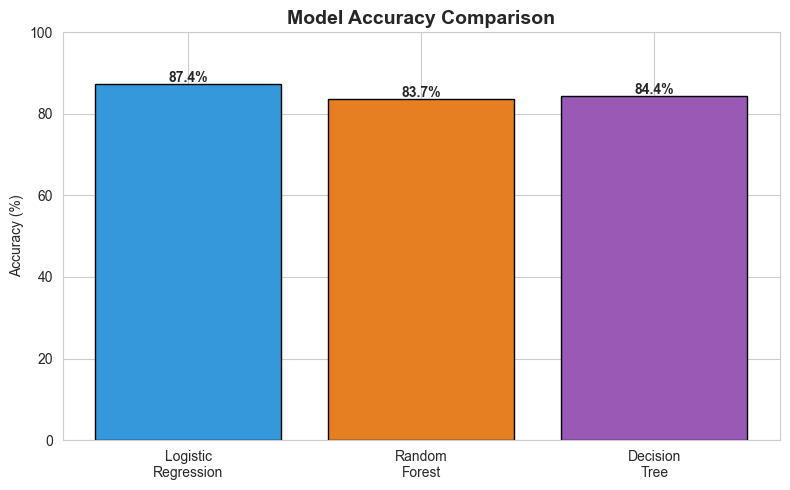

In [69]:
# --- Compare models visually ---
plt.figure(figsize=(8, 5))
models = ['Logistic\nRegression', 'Random\nForest', 'Decision\nTree']
accuracies = [lr_acc, rf_acc, dt_acc]
colors = ['#3498db', '#e67e22', '#9b59b6']

bars = plt.bar(models, [a*100 for a in accuracies], color=colors, edgecolor='black')
plt.title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)

# Add accuracy labels on bars
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
             f'{acc*100:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/charts/08_model_comparison.png')
plt.show()


The Code, Line by Line:

- `plt.ylim(0, 100)` - Y-axis limit - fixes range from - 0% to 100% , so chart stays consustent 

- `for bar, acc in zip(bars, accuracies):` - loops through each bar and its accuracy 

-  `plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,f'{acc*100:.1f}%', ha='center',fontweight='bold')` 

    - | Part                | Meaning               |
      | ------------------- | --------------------- |
      | `bar.get_x()`       | bar start position    |
      | `bar.get_width()/2` | center of bar         |
      | `bar.get_height()`  | top of bar            |
      | `+ 0.5`             | small space above bar |


**--- Confusion Matrix for best model (Random Forest) ---**
- A confusion matrix shows exactly where the model got confused


<Figure size 800x600 with 0 Axes>

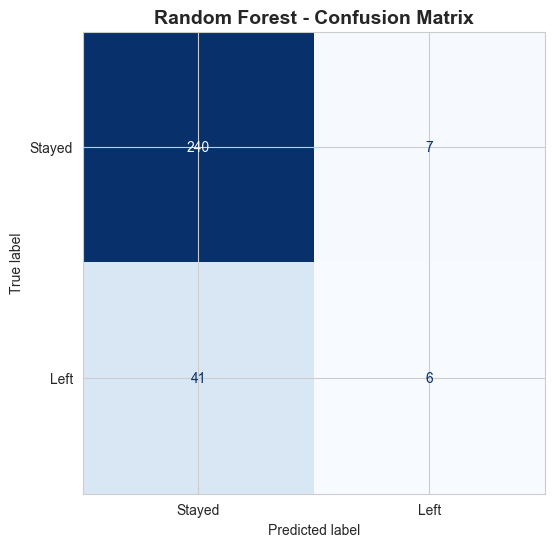


How to read the confusion matrix:
Top-left: Correctly predicted 'Stayed'
Top-right: Predicted 'Left' but actually 'Stayed' (False Alarm)
Bottom-left: Predicted 'Stayed' but actually 'Left' (Missed)
Bottom-right: Correctly predicted 'Left'


In [70]:

y_pred_rf = rf_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stayed', 'Left'])
disp.plot(cmap='Blues', colorbar=False)
plt.title('Random Forest - Confusion Matrix', fontsize=14, fontweight='bold')
plt.savefig('../outputs/charts/09_confusion_matrix.png')
plt.show()

print("\nHow to read the confusion matrix:")
print("Top-left: Correctly predicted 'Stayed'")
print("Top-right: Predicted 'Left' but actually 'Stayed' (False Alarm)")
print("Bottom-left: Predicted 'Stayed' but actually 'Left' (Missed)")
print("Bottom-right: Correctly predicted 'Left'")


The Code, Line by Line:

- The code creates **Confusion Matrix visualization** fro your best- performing model: **Random Forest** using scikit-learn.
    - this helps you see:
        - where the model predict correctly 
        - where it made mistakes, in detail 

- `y_pred_rf = rf_model.predict(X_test)` - predicting using Random Forest , employee attrition for unseen test data

- `cm = confusion_matrix(y_test, y_pred_rf)` - creates confusion matrix 
    - this compares:
        - actual answers (y_test)
        - predicted answers (y_pred_rf)
    - are builds the confusion matrix table

**What is confusion matrix?**
- it is a table showing 
    - correct predictions
    - incorrect predictions , for classification problems

- basic structure:
    - | Actual \ Predicted | Stayed          | Left                           |
      | ------------------ | ----------------| -------------------------------|
      | Stayed             | TN -correctyl predicted stayed | FP - predicted left but actually stayed |
      | Left               | FN - predicted stayed but actually left | TP - correctly predicted left |

- `disp = ConfusionMatrixDisplay( confusion_matrix=cm,display_labels=['Stayed', 'Left'])` - created a formatted confusion matrix visualization 
    - `display_labels` - changes class names from: 0/1 to Stayed/Left making the chart easier to understand

- Darker Blue - larger no. 
- Lighter blue - smaller no.



**--- Feature Importance: What factors matter most? ---**
- Random Forest can tell us which features (columns) it found most useful


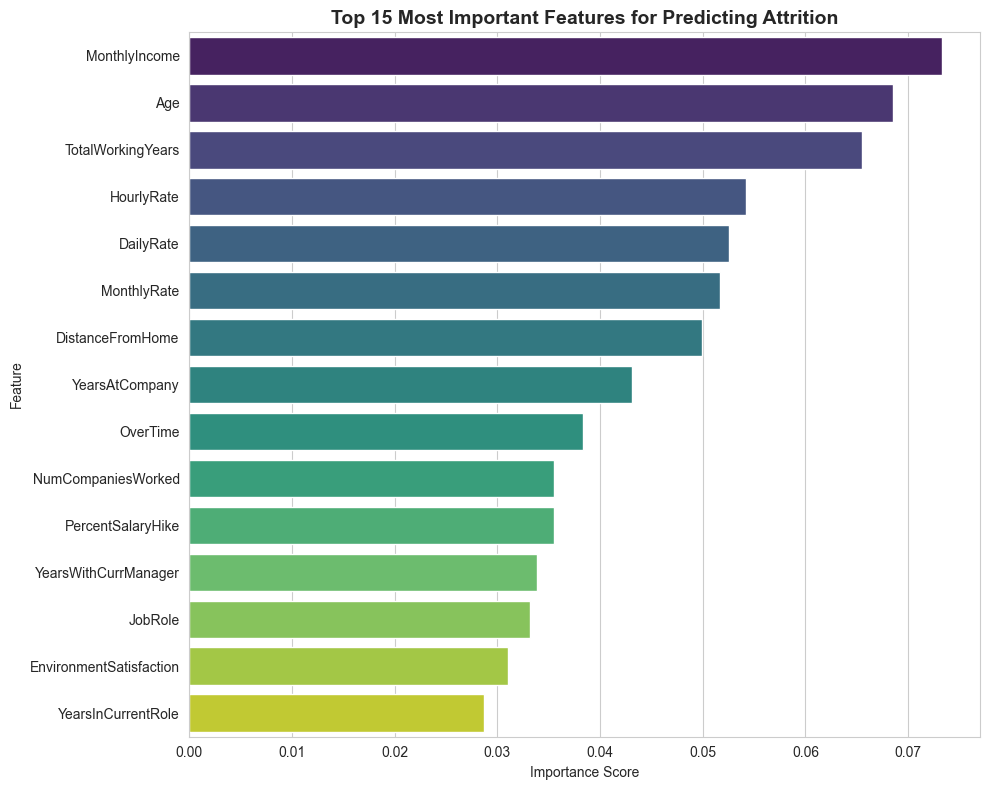


Top 5 factors that predict attrition:
  MonthlyIncome: 7.33%
  Age: 6.86%
  TotalWorkingYears: 6.55%
  HourlyRate: 5.42%
  DailyRate: 5.25%


In [71]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance, 
            palette='viridis')
plt.title('Top 15 Most Important Features for Predicting Attrition', 
          fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('../outputs/charts/10_feature_importance.png')
plt.show()

print("\nTop 5 factors that predict attrition:")
for i, row in feature_importance.head(5).iterrows():
    print(f"  {row['Feature']}: {row['Importance']*100:.2f}%")


The Code, Line by Line:

- Trained the `RandomForestClassifier` atore it in `rf_model` - so now we are looking "Which cloumns/features helped the model make decisions the most?"

- `feature_importance = pd.DataFrame({'Feature': X.columns,'Importance': rf_model.feature_importances_})` - Creating the features important table 
    - create a Padas DataFrame with 2 columns: Feature and Importance
    - `X.columns` - input fetures
    - `rf_model.feature_importances_` - generates automatically by Random Forest. It gives: Importance score to each feature 

- `.sort_values('Importance', ascending=False)` - Sorts features from: MOST important -> LEAST important 

- `.head(15)` - taking only the top 15 features



#### **Phase 7: Conclusions & Bussiness Insights**

In [72]:

print("""
=== PROJECT CONCLUSIONS ===

FINDINGS:
1. The overall attrition rate is approximately 16% of employees.
2. Employees who work overtime are significantly more likely to leave.
3. Lower monthly income is strongly linked to higher attrition.
4. Younger employees (20-35) show higher attrition rates.
5. The Sales department shows the highest attrition rate.
6. Low job satisfaction strongly predicts attrition.

BEST MODEL: Random Forest achieved the highest accuracy.

BUSINESS RECOMMENDATIONS:
1. Review overtime policies — reduce mandatory overtime where possible.
2. Conduct salary benchmarking for high-attrition departments.
3. Introduce targeted retention programs for young employees.
4. Improve job satisfaction through feedback programs.
5. Use this model to identify at-risk employees early and intervene.
""")



=== PROJECT CONCLUSIONS ===

FINDINGS:
1. The overall attrition rate is approximately 16% of employees.
2. Employees who work overtime are significantly more likely to leave.
3. Lower monthly income is strongly linked to higher attrition.
4. Younger employees (20-35) show higher attrition rates.
5. The Sales department shows the highest attrition rate.
6. Low job satisfaction strongly predicts attrition.

BEST MODEL: Random Forest achieved the highest accuracy.

BUSINESS RECOMMENDATIONS:
1. Review overtime policies — reduce mandatory overtime where possible.
2. Conduct salary benchmarking for high-attrition departments.
3. Introduce targeted retention programs for young employees.
4. Improve job satisfaction through feedback programs.
5. Use this model to identify at-risk employees early and intervene.

